# Importation de csv, jointures attributaires, calculs d'indicateurs et cartographie thématique
Ce notebook propose un ensemble d'exercices autour de la préparation, l'analyse et la carrtographie de données sur la démographie et les logements à Paris

# 🧰 Configuration de l'environnement de travail

In [ ]:
#Initialisation de l'environnement avec geopandas
!apt update
!apt install gdal-bin python-gdal python3-gdal
!apt install python3-rtree
! pip install geopandas
! pip install matplotlib
!pip install contextily
!pip install pygeos
!pip install mapclassify
!pip install folium
!pip install matplotlib_scalebar

In [2]:
#Importation des librairies nécessaires

import pandas as pd #Gestion de données
import matplotlib.pyplot as plt #Visualisation de données
import seaborn # Visualisation de données avancée
import geopandas as gpd #Gestion données spatiales
import contextily as ctx #Fonds de carte
import numpy as np #Manipulation de tableaux
import shapely #Manipulation de géométrie
import folium #Cartographie interactive
import mapclassify #Cartographie thématique
from matplotlib_scalebar.scalebar import ScaleBar #Echelle cartographique

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

# 📥 Importer et préparer les couches IRIS et Arrondissements


In [ ]:
#Téléchargement des datas depuis le site opendata de Paris

!wget -O IRIS.geojson https://data.iledefrance.fr/explore/dataset/iris/download/?format=geojson&refine.dep=75&timezone=Europe/Berlin&lang=fr

,typ_iris,insee_com,code_iris,nom_iris,dep,geo_point_2d,id,iris,nom_com,geometry
0,A,93063,930630101,Bas Pays,93,"[48.89469105740408, 2.4339936032886005]",IRIS____0000000930630101,0101,Romainville,"POLYGON ((2.42661 48.89287, 2.42773 48.8959, 2..."
1,H,78644,786440101,Bois de l'Étang,78,"[48.75889363749545, 1.9646913934927093]",IRIS____0000000786440101,0101,La Verrière,"POLYGON ((1.96799 48.75603, 1.9678 48.756, 1.9..."
2,H,77053,770530101,Leclerc-Centre Ouest,77,"[48.69188538671072, 2.5913435285805986]",IRIS____0000000770530101,0101,Brie-Comte-Robert,"POLYGON ((2.58565 48.67894, 2.58524 48.67914, ..."
3,H,78642,786420101,Les Hauts de Verneuil,78,"[48.97382146811184, 1.9620723275040297]",IRIS____0000000786420101,0101,Verneuil-sur-Seine,"POLYGON ((1.97667 48.97476, 1.97554 48.97391, ..."
4,H,94019,940190102,Centre Ville Château,94,"[48.79027005018674, 2.527242899604056]",IRIS____0000000940190102,0102,Chennevières-sur-Marne,"POLYGON ((2.5326 48.79205, 2.53196 48.79049, 2..."


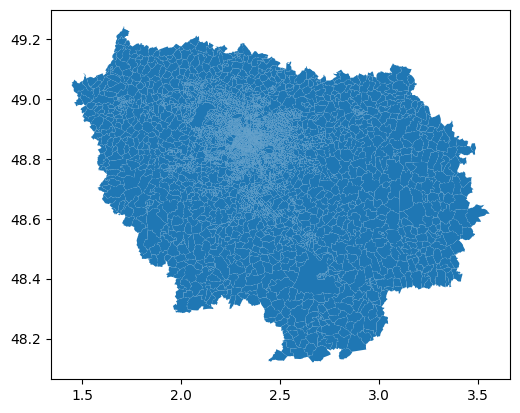

In [5]:
#Importer le couche des IRIS
IRIS= gpd.read_file("IRIS.geojson", encoding='utf-8')
IRIS.plot()
IRIS.head(5)

,typ_iris,insee_com,code_iris,nom_iris,dep,geo_point_2d,id,iris,nom_com,geometry
35,H,75110,751103801,Porte Saint-Denis 1,75,"[48.874427462595776, 2.3561996940137764]",IRIS____0000000751103801,3801,Paris 10e Arrondissement,"POLYGON ((2.3573 48.87492, 2.35715 48.87469, 2..."
36,H,75111,751114113,Folie Méricourt 13,75,"[48.869840735611575, 2.374642944766014]",IRIS____0000000751114113,4113,Paris 11e Arrondissement,"POLYGON ((2.3729 48.87057, 2.37466 48.87125, 2..."
37,H,75115,751155815,Necker 15,75,"[48.84295460280127, 2.3150020883912683]",IRIS____0000000751155815,5815,Paris 15e Arrondissement,"POLYGON ((2.31319 48.84217, 2.31259 48.84293, ..."


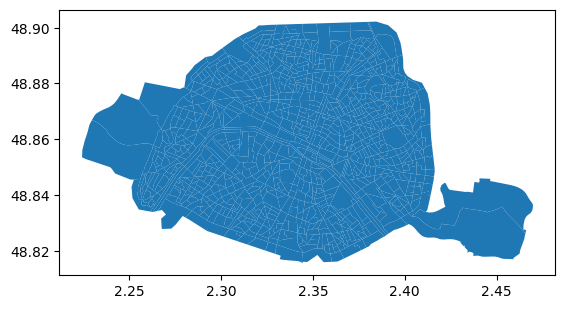

In [63]:
#Garder uniquement les IRIS de Paris
IRISPARIS = IRIS[(IRIS["dep"] == "75")]
IRISPARIS.plot()
IRISPARIS.head(3)

## Ajouter la couche des arrondissements de Paris


In [7]:
# URL : https://opendata.paris.fr/explore/dataset/arrondissements/export/?disjunctive.l_ar&disjunctive.c_arinsee&disjunctive.c_ar


,n_sq_ar,c_ar,c_arinsee,l_ar,l_aroff,n_sq_co,surface,perimetre,geom_x_y,geometry
0,750000012,12,75112,12ème Ardt,Reuilly,750001537,1.631478e+07,24089.666298,"{'lon': 2.4213235156144646, 'lat': 48.83497415...","POLYGON ((2.41388 48.83357, 2.41401 48.83357, ..."
1,750000010,10,75110,10ème Ardt,Entrepôt,750001537,2.891739e+06,6739.375055,"{'lon': 2.360728487847452, 'lat': 48.876130036...","POLYGON ((2.36469 48.88437, 2.36485 48.88436, ..."
2,750000018,18,75118,18ème Ardt,Buttes-Montmartre,750001537,5.996051e+06,9916.464176,"{'lon': 2.3481605195620396, 'lat': 48.89256926...","POLYGON ((2.3658 48.88554, 2.36469 48.88437, 2..."
3,750000001,1,75101,1er Ardt,Louvre,750001537,1.824613e+06,6054.936862,"{'lon': 2.3364433620533878, 'lat': 48.86256270...","POLYGON ((2.32801 48.86992, 2.32997 48.86851, ..."
4,750000003,3,75103,3ème Ardt,Temple,750001537,1.170883e+06,4519.263648,"{'lon': 2.360000985897692, 'lat': 48.862872380...","POLYGON ((2.36383 48.8675, 2.36389 48.86747, 2..."


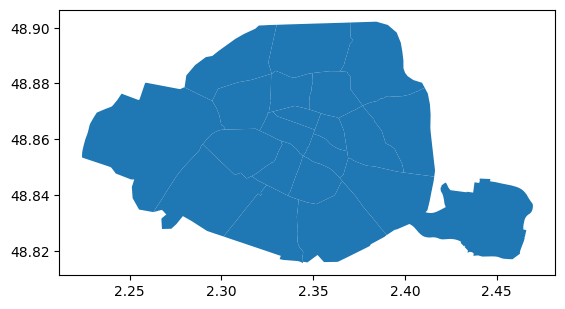

In [65]:
#Importer le jeu de données dans l'espace de travail puis le convertir en gdf

Ardt= gpd.read_file("arrondissements.geojson", encoding='utf-8')
Ardt.plot()
Ardt.head()

# 🗺️ Cartographier la Densité de population

## Récupérer le fichier de population

Documentation : https://opendata.apur.org/datasets/recensement-iris-population/explore?location=48.841266%2C2.410137%2C11

In [ ]:
#Téléchargement des datas depuis l'opendata (https://opendata.apur.org/datasets/recensement-iris-population/geoservice)
!wget -O population.csv https://data.smartidf.services/api/explore/v2.1/catalog/datasets/recensement-iris-population/exports/csv?lang=fr&timezone=Europe%2FBerlin&use_labels=true&delimiter=%3B


In [67]:
#Importer CSV to dataframe

population = pd.read_csv("population.csv", sep=';')
population.head(3)

,geo_point_2d,geo_shape,irisobject,irisn_sq_i,irisc_cain,irisn_qu,irisc_ir,irisc_type,irisl_ir,irism2_ip,...,iris_20275,iris_20276,iris_20277,iris_20278,iris_20279,iris_20280,iris_20281,iris_20282,iris_20283,iris_20284
0,"48.8935667974705, 2.382466377796605","{""coordinates"": [[[2.384372199855532, 48.89452...",2513,750004038.0,75119,74.0,751197405,H,Pont de Flandre 5,54952.126842,...,180.511418,7.598027,119.003062,4.878397,51.686364,50.718565,12.636349,52.293749,22.942730,-3.012184
1,"48.893969230093376, 2.37922987575422","{""coordinates"": [[[2.381707536912838, 48.89430...",2514,750004047.0,75119,74.0,751197406,H,Pont de Flandre 6,54097.316293,...,354.858585,7.611190,339.592550,6.214057,4.495398,106.868358,15.581553,135.829016,16.110821,-21.321408
2,"48.81871932117911, 2.4219776446131","{""coordinates"": [[[2.423372970295083, 48.82016...",2517,940001607.0,94069,0.0,940690101,H,Ouest Quartier du Pont,70934.372157,...,209.048818,5.973085,192.961250,6.065338,8.337201,50.666021,11.446453,46.618557,10.088623,8.682088


## Préparer le fichier

In [68]:
# Ne garder que les colonne importantes

PopulationOK = population[["irisc_ir", "irisl_ir", "iris_202_3"]]
PopulationOK.head()

,irisc_ir,irisl_ir,iris_202_3
0,751197405,Pont de Flandre 5,2375.766978
1,751197406,Pont de Flandre 6,4662.327160
2,940690101,Ouest Quartier du Pont,3499.846735
3,940710101,Le Grand Val,2149.341109
4,940730107,La Prevote,2531.820966


In [69]:
#Renommer les colonnes

PopulationOK = PopulationOK.rename(columns={'irisc_ir': 'Code_IRIS', 'irisl_ir':'Libelle', 'iris_202_3': 'Population'})
PopulationOK.head()

,Code_IRIS,Libelle,Population
0,751197405,Pont de Flandre 5,2375.766978
1,751197406,Pont de Flandre 6,4662.327160
2,940690101,Ouest Quartier du Pont,3499.846735
3,940710101,Le Grand Val,2149.341109
4,940730107,La Prevote,2531.820966


In [70]:
PopulationOK.dtypes

,0
Code_IRIS,int64
Libelle,object
Population,float64


In [71]:
#Changer le type d'une colonne
PopulationOK['Code_IRIS'] = PopulationOK['Code_IRIS'].astype(str)

## Jointure attributaire

In [72]:
IRISPARIS.head(3)

,typ_iris,insee_com,code_iris,nom_iris,dep,geo_point_2d,id,iris,nom_com,geometry
35,H,75110,751103801,Porte Saint-Denis 1,75,"[48.874427462595776, 2.3561996940137764]",IRIS____0000000751103801,3801,Paris 10e Arrondissement,"POLYGON ((2.3573 48.87492, 2.35715 48.87469, 2..."
36,H,75111,751114113,Folie Méricourt 13,75,"[48.869840735611575, 2.374642944766014]",IRIS____0000000751114113,4113,Paris 11e Arrondissement,"POLYGON ((2.3729 48.87057, 2.37466 48.87125, 2..."
37,H,75115,751155815,Necker 15,75,"[48.84295460280127, 2.3150020883912683]",IRIS____0000000751155815,5815,Paris 15e Arrondissement,"POLYGON ((2.31319 48.84217, 2.31259 48.84293, ..."


In [73]:
# Faire la jointure attributaire

IRISPARIS = IRISPARIS.merge(PopulationOK, left_on='code_iris', right_on='Code_IRIS')
IRISPARIS.head()

,typ_iris,insee_com,code_iris,nom_iris,dep,geo_point_2d,id,iris,nom_com,geometry,Code_IRIS,Libelle,Population
0,H,75110,751103801,Porte Saint-Denis 1,75,"[48.874427462595776, 2.3561996940137764]",IRIS____0000000751103801,3801,Paris 10e Arrondissement,"POLYGON ((2.3573 48.87492, 2.35715 48.87469, 2...",751103801,Porte Saint-Denis 1,1854.705768
1,H,75111,751114113,Folie Méricourt 13,75,"[48.869840735611575, 2.374642944766014]",IRIS____0000000751114113,4113,Paris 11e Arrondissement,"POLYGON ((2.3729 48.87057, 2.37466 48.87125, 2...",751114113,Folie Mericourt 13,1419.142305
2,H,75115,751155815,Necker 15,75,"[48.84295460280127, 2.3150020883912683]",IRIS____0000000751155815,5815,Paris 15e Arrondissement,"POLYGON ((2.31319 48.84217, 2.31259 48.84293, ...",751155815,Necker 15,2248.341905
3,H,75116,751166221,Muette 21,75,"[48.85980874635298, 2.2876243156612777]",IRIS____0000000751166221,6221,Paris 16e Arrondissement,"POLYGON ((2.28659 48.86206, 2.2868 48.86234, 2...",751166221,Muette 21,1815.952591
4,H,75117,751176507,Ternes 7,75,"[48.881330014818424, 2.287279098386447]",IRIS____0000000751176507,6507,Paris 17e Arrondissement,"POLYGON ((2.28996 48.88085, 2.28839 48.87999, ...",751176507,Ternes 7,2436.509939


In [74]:
# Vérifier la popuation de Paris

sum(IRISPARIS["Population"])

2133111.0

## Calcul des indicateurs

In [75]:
# Reprojeter la couche IRIS pour le calcul de surface

IRIS2154 = IRISPARIS.to_crs(2154)
IRIS2154.crs

<Projected CRS: EPSG:2154>
Name: RGF93 v1 / Lambert-93
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: France - onshore and offshore, mainland and Corsica (France métropolitaine including Corsica).
- bounds: (-9.86, 41.15, 10.38, 51.56)
Coordinate Operation:
- name: Lambert-93
- method: Lambert Conic Conformal (2SP)
Datum: Reseau Geodesique Francais 1993 v1
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [76]:
# Ajouter une colonne Surface à la couche des IRIS

IRIS2154["surface"] = IRIS2154['geometry'].area/1000000
IRIS2154.head(3)

,typ_iris,insee_com,code_iris,nom_iris,dep,geo_point_2d,id,iris,nom_com,geometry,Code_IRIS,Libelle,Population,surface
0,H,75110,751103801,Porte Saint-Denis 1,75,"[48.874427462595776, 2.3561996940137764]",IRIS____0000000751103801,3801,Paris 10e Arrondissement,"POLYGON ((652859.7 6864068.7, 652848.3 6864043...",751103801,Porte Saint-Denis 1,1854.705768,0.052726
1,H,75111,751114113,Folie Méricourt 13,75,"[48.869840735611575, 2.374642944766014]",IRIS____0000000751114113,4113,Paris 11e Arrondissement,"POLYGON ((653999.9 6863576.4, 654130.1 6863650...",751114113,Folie Mericourt 13,1419.142305,0.036870
2,H,75115,751155815,Necker 15,75,"[48.84295460280127, 2.3150020883912683]",IRIS____0000000751155815,5815,Paris 15e Arrondissement,"POLYGON ((649592.9 6860455, 649549.5 6860540, ...",751155815,Necker 15,2248.341905,0.050197


In [77]:
#Calculer la densité de population des IRIS

IRIS2154["Densite"] = IRIS2154["Population"] / IRIS2154["surface"]
IRIS2154.head(3)

,typ_iris,insee_com,code_iris,nom_iris,dep,geo_point_2d,id,iris,nom_com,geometry,Code_IRIS,Libelle,Population,surface,Densite
0,H,75110,751103801,Porte Saint-Denis 1,75,"[48.874427462595776, 2.3561996940137764]",IRIS____0000000751103801,3801,Paris 10e Arrondissement,"POLYGON ((652859.7 6864068.7, 652848.3 6864043...",751103801,Porte Saint-Denis 1,1854.705768,0.052726,35176.313319
1,H,75111,751114113,Folie Méricourt 13,75,"[48.869840735611575, 2.374642944766014]",IRIS____0000000751114113,4113,Paris 11e Arrondissement,"POLYGON ((653999.9 6863576.4, 654130.1 6863650...",751114113,Folie Mericourt 13,1419.142305,0.036870,38490.230512
2,H,75115,751155815,Necker 15,75,"[48.84295460280127, 2.3150020883912683]",IRIS____0000000751155815,5815,Paris 15e Arrondissement,"POLYGON ((649592.9 6860455, 649549.5 6860540, ...",751155815,Necker 15,2248.341905,0.050197,44790.301609


Text(0.5, 0, "Nombre d'habitants")

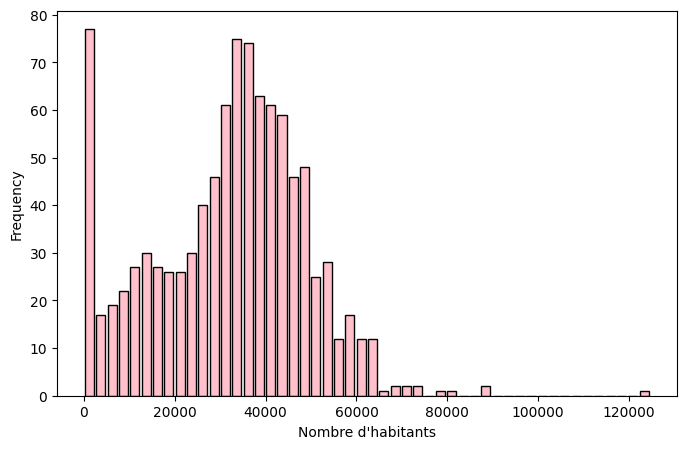

In [78]:
# Histogramme de distribution des densités de population par IRIS

ax = IRIS2154.plot.hist(y='Densite', figsize=(8, 5), bins=50, rwidth=0.8, edgecolor='black', color='pink',legend=False)
ax.set_xlabel("Nombre d'habitants")

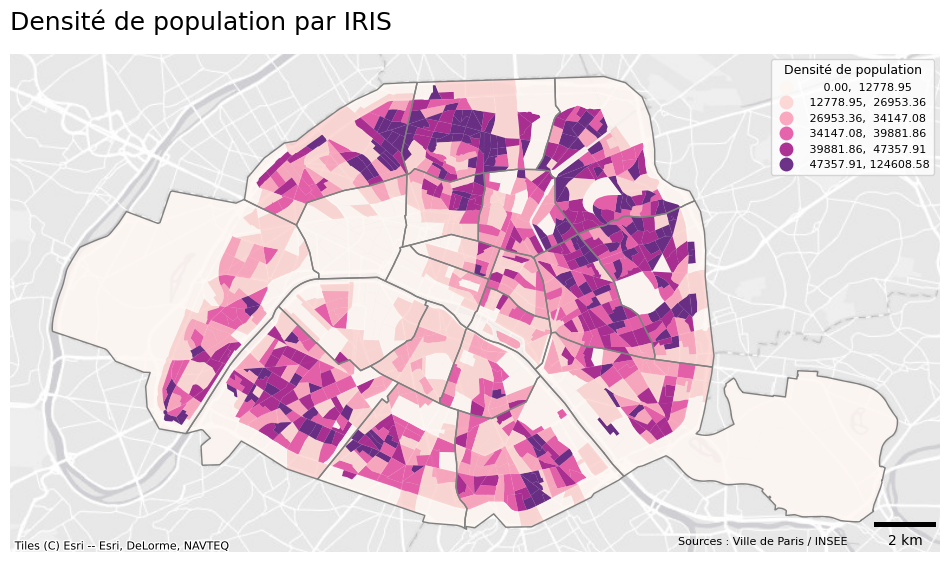

In [79]:
# Faire une carte des densité de population par IRIS

Carte1, ax = plt.subplots(figsize=(12,12))

Ardt.boundary.to_crs('EPSG:3857').plot(ax=ax, linewidth=1, color = 'grey') # Appel couche arrondissements
IRIS2154.to_crs('EPSG:3857').plot(ax=ax,column="Densite", cmap='RdPu', k =6, scheme='quantiles', alpha=0.8, legend=True,
                                    legend_kwds={'title': "Densité de population", 'loc': 'upper right', 'title_fontsize':9, 'fontsize':8})

ctx.add_basemap(ax,source=ctx.providers.Esri.WorldGrayCanvas)

# On enlève les axes
ax.axis("off")

# Ajout du titre de la carte
plt.title("Densité de population par IRIS", loc='left', fontsize=18)

#Ajout d'une échelle
ax.add_artist(ScaleBar(1, length_fraction=0.1, location = "lower right", box_alpha=0, color="black"))

# Ajout des sources
ax.text(0.90, 0.01, 'Sources : Ville de Paris / INSEE', verticalalignment='bottom', horizontalalignment='right',
        transform=ax.transAxes, color='black', fontsize=8)

plt.show() #Génération de la carte

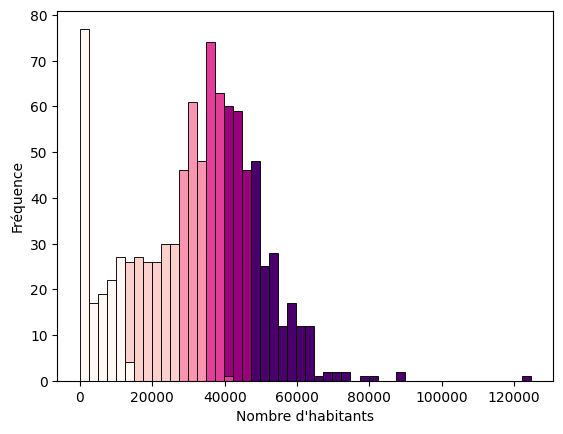

In [80]:
# Histogramme en fonction de la discrétisation de la carte

import seaborn as sns

# Nombre de quantiles
num_quantiles = 6

# Calculer les quantiles
quantiles = pd.qcut(IRIS2154['Densite'], num_quantiles, labels=False)

# Tracer l'histogramme avec des couleurs de quantiles en utilisant Seaborn
sns.histplot(data=IRIS2154, x='Densite', bins=50, hue=quantiles, palette='RdPu',  alpha=1, legend=False)

# Définir les étiquettes des axes
plt.xlabel("Nombre d'habitants")
plt.ylabel("Fréquence")

# Afficher le graphe
plt.show()

## Exercices en autonomie

* Faire la carte pour d'autres départements en affichant les contours des communes https://public.opendatasoft.com/explore/assets/georef-france-commune/view/

* Faire la carte pour le tx d'étudiants par IRIS (colonne : "iris_20278")


# 🏢 Exercice avec les données de logement des IRIS

https://opendata.apur.org/datasets/Apur::recensement-iris-logement/explore?location=48.679050%2C2.519850%2C9&showTable=true

* Produire une carte avec en aplat de couleur le taux de logement vacant
* Produire une carte avec en aplat de couleur le taux de sociaux
* Produire une carte avec en cercle proportionnels le nombre de logement sociaux




In [ ]:
#Téléchargement des datas depuis l'opendata ( https://data.smartidf.services/api/explore/v2.1/catalog/datasets/recensement-iris-logement/exports/csv?lang=fr&timezone=Europe%2FBerlin&use_labels=true&delimiter=%3B)


In [ ]:
#Importer CSV to dataframe


,geo_point_2d,geo_shape,irisobject,irisn_sq_i,irisc_cain,irisn_qu,irisc_ir,irisc_type,irisl_ir,irism2_ip,...,iris_20290,iris_20291,iris_20292,iris_20293,iris_20294,iris_20295,iris_20296,iris_20297,iris_20298,iris_20299
0,"48.85660919498049, 2.407588415018213","{""coordinates"": [[[2.409279236465015, 48.85666...",2503,750004548.0,75120,80.0,751208011,H,Charonne 11,23277.638604,...,0.726787,51.905792,750.657461,706.710644,84.785115,89.046931,6.218502,209.095019,209.095019,10.991999
1,"48.88614534962963, 2.374959631079119","{""coordinates"": [[[2.383065382237795, 48.88990...",2508,750004096.0,75119,73.0,751197388,D,Bassin de La Villette,67132.249904,...,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2,"48.89744626583246, 2.390421388219987","{""coordinates"": [[[2.395723446317495, 48.89793...",2509,750004859.0,75119,74.0,751197401,H,Pont de Flandre 1,414026.868222,...,0.000000,NaN,972.946473,422.849152,77.118610,82.424579,130.093041,139.306344,139.306344,6.711946


In [ ]:
# Ne garder que les colonne importantes et les renommer

LogementOK = logement[["irisc_ir", "irisl_ir", "iris_202_8", "iris_20224", "iris_20246"]]
LogementOK = LogementOK.rename(columns={'irisc_ir': 'Code_IRIS', 'irisl_ir':'Libelle', 'iris_202_8': 'nb_logements',"iris_20224": "nb_logvacants", "iris_20246": "nb_logsociaux"})

LogementOK.head()

,Code_IRIS,Libelle,nb_logements,nb_logvacants,nb_logsociaux
0,751208011,Charonne 11,829.501592,34.731332,658.551017
1,751197388,Bassin de La Villette,0.000000,0.000000,0.000000
2,751197401,Pont de Flandre 1,1247.502229,87.990499,203.655392
3,751197406,Pont de Flandre 6,2175.003864,166.654848,939.684317
4,940680704,La Pie 4,1142.506017,71.082086,6.091991


In [ ]:
#Changer le type d'une colonne pour le code iris


In [ ]:
# Faire la jointure attributaire


,typ_iris,insee_com,code_iris,nom_iris,dep,geo_point_2d,id,iris,nom_com,geometry,Code_IRIS,Libelle,nb_logements,nb_logvacants,nb_logsociaux
0,A,75112,751124811,Quinze-Vingts 11,75,"[48.844104305775815, 2.3753123018512237]",IRIS____0000000751124811,4811,Paris 12e Arrondissement,"POLYGON ((2.37114 48.84553, 2.37268 48.84568, ...",751124811,Quinze Vingts 11,0.000000,0.0,0.000000
1,D,75115,751156023,Jardin Citroën-Cévennes,75,"[48.840354178960965, 2.2752169001780462]",IRIS____0000000751156023,6023,Paris 15e Arrondissement,"POLYGON ((2.2746 48.84352, 2.27488 48.84342, 2...",751156023,Jardin Citroen Cevennes,63.151685,0.0,52.626405


In [ ]:
#Calculer le taux de logements vacants


,typ_iris,insee_com,code_iris,nom_iris,dep,geo_point_2d,id,iris,nom_com,geometry,Code_IRIS,Libelle,nb_logements,nb_logvacants,nb_logsociaux,txlogvac
0,A,75112,751124811,Quinze-Vingts 11,75,"[48.844104305775815, 2.3753123018512237]",IRIS____0000000751124811,4811,Paris 12e Arrondissement,"POLYGON ((2.37114 48.84553, 2.37268 48.84568, ...",751124811,Quinze Vingts 11,0.000000,0.000000,0.000000,NaN
1,D,75115,751156023,Jardin Citroën-Cévennes,75,"[48.840354178960965, 2.2752169001780462]",IRIS____0000000751156023,6023,Paris 15e Arrondissement,"POLYGON ((2.2746 48.84352, 2.27488 48.84342, 2...",751156023,Jardin Citroen Cevennes,63.151685,0.000000,52.626405,0.000000
2,A,75108,751083006,Faubourg du Roule 6,75,"[48.874120601261225, 2.308949350470029]",IRIS____0000000751083006,3006,Paris 8e Arrondissement,"POLYGON ((2.31153 48.87307, 2.31076 48.87282, ...",751083006,Faubourg du Roule 6,360.564204,55.962958,0.000000,15.520941


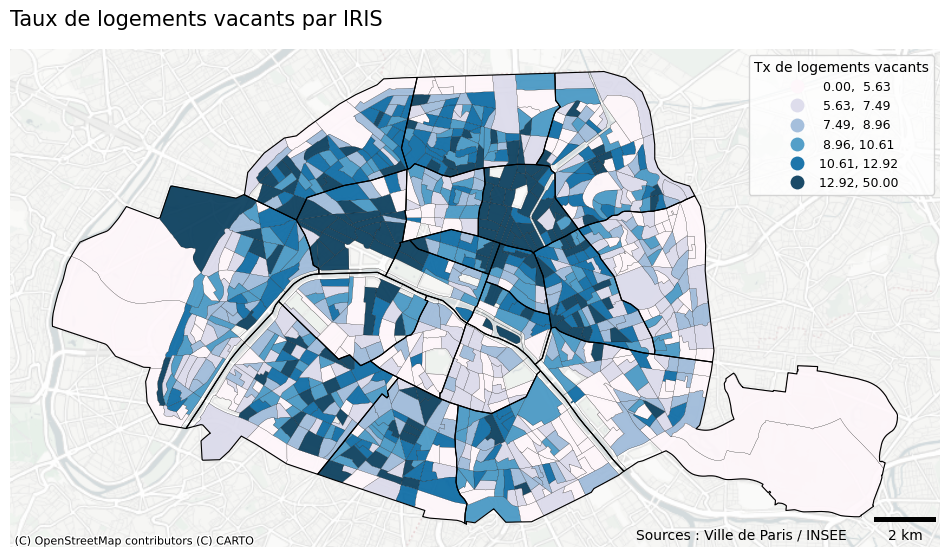

In [ ]:
#Faire une carte du taux de logements vacants par IRIS

Carte4, ax = plt.subplots(figsize=(12,12))

Ardt.boundary.to_crs('EPSG:3857').plot(ax=ax, linewidth=0.8, color = 'black')
IRISLogements.boundary.to_crs('EPSG:3857').plot(ax=ax, linewidth=0.1, color = 'black')
IRISLogements.to_crs('EPSG:3857').plot(ax=ax, k=6, column='txlogvac', cmap='PuBu',scheme='quantiles', alpha=0.9,
                                    legend=True, legend_kwds={'title': "Tx de logements vacants", 'loc': 'upper right', 'title_fontsize':10, 'fontsize':9})
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels)

ax.axis("off")
plt.title('Taux de logements vacants par IRIS', loc='left', fontsize=15)
ax.text(0.90, 0.01, 'Sources : Ville de Paris / INSEE', verticalalignment='bottom', horizontalalignment='right',
        transform=ax.transAxes, color='black', fontsize=10)
ax.add_artist(ScaleBar(1, length_fraction=0.1, location = "lower right", box_alpha=0, color="black"))

plt.show()

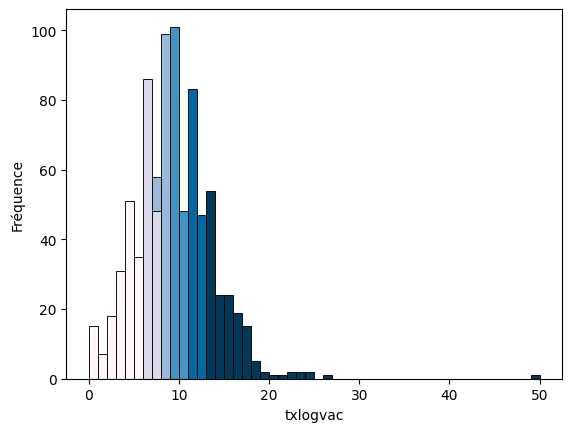

In [ ]:
# Histogramme en fonction de la discrétisation de la carte

import seaborn as sns

# Nombre de quantiles
num_quantiles = 6

# Calculer les quantiles
quantiles = pd.qcut(IRISLogements['txlogvac'], num_quantiles, labels=False)

# Tracer l'histogramme avec des couleurs de quantiles en utilisant Seaborn
sns.histplot(data=IRISLogements, x='txlogvac', bins=50, hue=quantiles, palette='PuBu',  alpha=1, legend=False)

# Définir les étiquettes des axes
plt.xlabel("txlogvac")
plt.ylabel("Fréquence")

# Afficher le graphe
plt.show()

In [ ]:
# Calculer le taux de logements sociaux par IRIS


,typ_iris,insee_com,code_iris,nom_iris,dep,geo_point_2d,id,iris,nom_com,geometry,Code_IRIS,Libelle,nb_logements,nb_logvacants,nb_logsociaux,txlogvac,Txlogsocial
0,A,75112,751124811,Quinze-Vingts 11,75,"[48.844104305775815, 2.3753123018512237]",IRIS____0000000751124811,4811,Paris 12e Arrondissement,"POLYGON ((2.37114 48.84553, 2.37268 48.84568, ...",751124811,Quinze Vingts 11,0.000000,0.0,0.000000,NaN,NaN
1,D,75115,751156023,Jardin Citroën-Cévennes,75,"[48.840354178960965, 2.2752169001780462]",IRIS____0000000751156023,6023,Paris 15e Arrondissement,"POLYGON ((2.2746 48.84352, 2.27488 48.84342, 2...",751156023,Jardin Citroen Cevennes,63.151685,0.0,52.626405,0.0,83.333333


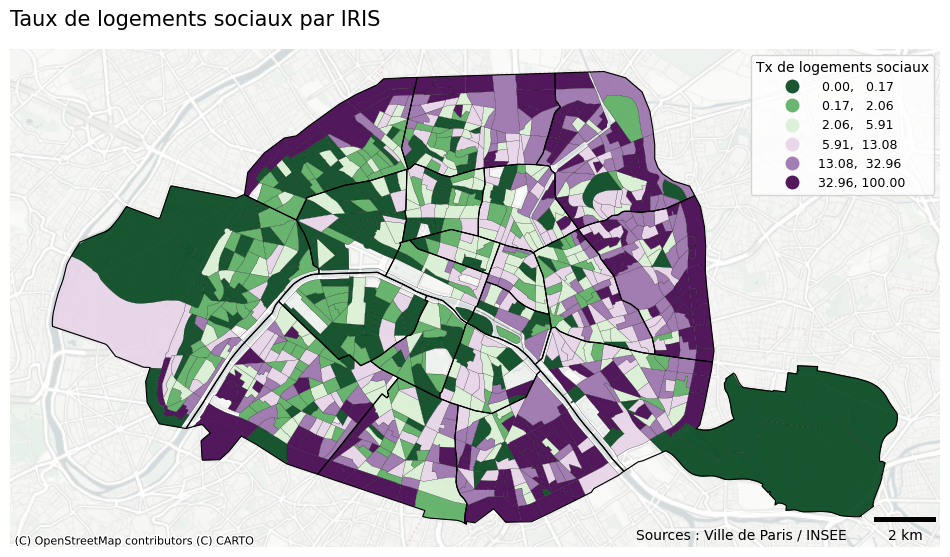

In [ ]:
#Faire une carte du taux de logements sociaux par IRIS


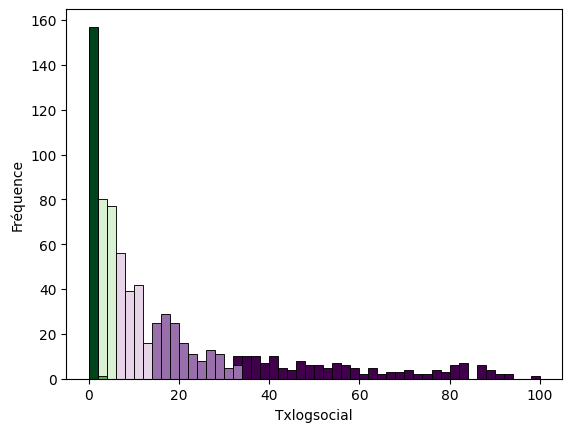

In [ ]:
# Histogramme en fonction de la discrétisation de la carte



/tmp/ipykernel_647/1665852430.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  IRIScentro.geometry = IRIScentro['geometry'].centroid


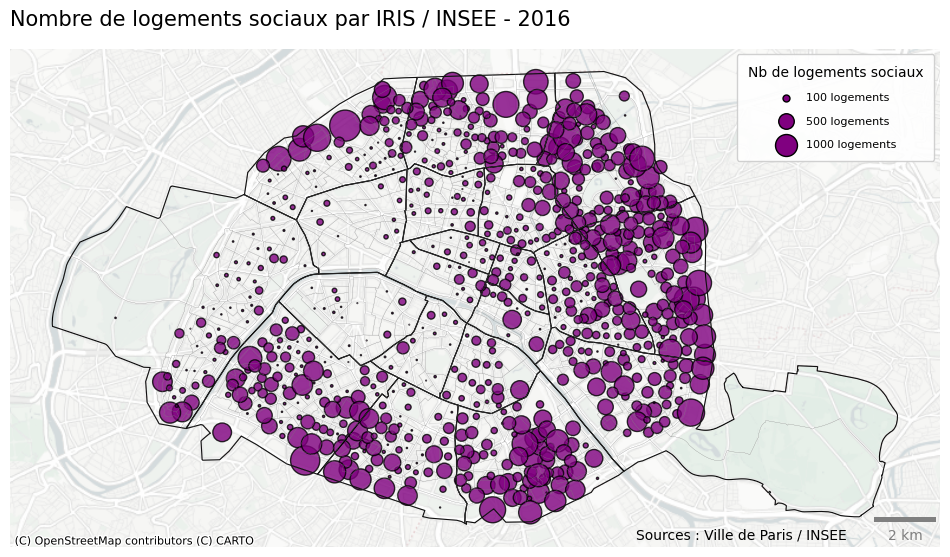

In [ ]:
# Faire une carte du nombre de logements sociaux par IRIS


## Commencer par créer un geodataframe  des IRIS sous forme de points
IRIScentro = IRISLogements.copy()
IRIScentro.geometry = IRIScentro['geometry'].centroid


## Faire la carte

Carte5, ax = plt.subplots(figsize=(12,12))

Ardt.boundary.to_crs('EPSG:3857').plot(ax=ax, linewidth=0.8, color = 'black')
IRISLogements.boundary.to_crs('EPSG:3857').plot(ax=ax, linewidth=0.1, color = 'grey')
IRIScentro.to_crs('EPSG:3857').plot(ax=ax, markersize=IRIScentro["nb_logsociaux"]/4, alpha=0.8, color="purple", edgecolor= "black")

ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels)

ax.axis("off")
plt.title('Nombre de logements sociaux par IRIS / INSEE - 2016', loc='left', fontsize=15)
ax.text(0.90, 0.01, 'Sources : Ville de Paris / INSEE', verticalalignment='bottom', horizontalalignment='right',
        transform=ax.transAxes, color='black', fontsize=10)
ax.add_artist(ScaleBar(1, length_fraction=0.1, location = "lower right", box_alpha=0, color="grey"))

# Ajouter une légende manuelle
legend_sizes = [100, 500, 1000]
legend_handles = [plt.scatter([], [], s=s/4, color='purple', edgecolor="black") for s in legend_sizes]

ax.legend(legend_handles, [f"{s} logements" for s in legend_sizes],
          title="Nb de logements sociaux", loc="upper right", fontsize=8, title_fontsize=10,
          frameon=True, framealpha=0.9, borderpad=1, labelspacing=1.2, bbox_to_anchor=(1, 1))

plt.show()

## Exercices en autonomie


### Faire la carte du tx de locataire par IRIS

iris_20235 = pourcentage de propriétaire

### Faire la carte du nombre de logements insalubres par IRIS

iris_20297 = nombre de logements insalubres


### Faire une planche avec trois cartes

Exemples : https://coderzcolumn.com/tutorials/data-science/plotting-static-maps-with-geopandas-working-with-geospatial-data#4



